### Architecture 1: Custom CNN

####  Train multiple classification architectures. At minimum, train and compare:
##### 1. A custom CNN designed from scratch (your team chooses depth, channel counts, regularization).

#### 0. Environment setup (local Jupyter or Google Colab)
On **Colab**: `Runtime -> Change runtime type -> T4 GPU` (CPU also works, just slower), then run this cell.
By default it mounts Google Drive and uses (or clones) the repo at `MyDrive/IE7615-Group3-Project1`, so results,
logs and checkpoints persist after the session ends. Cloning the private repo needs a GitHub personal access token
saved as a Colab secret named `GITHUB_TOKEN` (key icon in the left sidebar). Locally, the cell just finds the repo root.

In [ ]:
import os, sys, subprocess
from pathlib import Path

REPO_URL = "https://github.com/rasmussenj03/IE7615-Group3-Project1.git"
COLAB_USE_DRIVE = True  # False -> clone into /content (outputs are lost when the runtime ends)
COLAB_REPO_DIR = ("/content/drive/MyDrive/IE7615-Group3-Project1" if COLAB_USE_DRIVE
                  else "/content/IE7615-Group3-Project1")

if "google.colab" in sys.modules:
    if COLAB_USE_DRIVE:
        from google.colab import drive
        drive.mount("/content/drive")
    if not Path(COLAB_REPO_DIR, "src").is_dir():
        from google.colab import userdata
        token = userdata.get("GITHUB_TOKEN")  # Colab secret holding a GitHub access token
        clone = subprocess.run(["git", "clone", "-q", REPO_URL.replace("https://", f"https://{token}@"),
                                COLAB_REPO_DIR], capture_output=True)
        if clone.returncode != 0:
            raise RuntimeError("git clone failed - check the GITHUB_TOKEN secret and repo access")
        subprocess.run(["git", "-C", COLAB_REPO_DIR, "remote", "set-url", "origin", REPO_URL])
    os.chdir(COLAB_REPO_DIR)
else:
    root = Path.cwd()
    while not (root / "src" / "preprocessing.py").exists() and root != root.parent:
        root = root.parent
    os.chdir(root)

PROJECT_ROOT = Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import torch
print("Project root:", PROJECT_ROOT)
print("PyTorch", torch.__version__, "| device:", "cuda - " + torch.cuda.get_device_name(0)
      if torch.cuda.is_available() else "cpu")

Mounted at /content/drive
Project root: /content/drive/MyDrive/IE7615-Group3-Project1
PyTorch 2.11.0+cu128 | device: cuda - Tesla T4


#### 1. Import Pre-Processed Data

In [ ]:
import pandas as pd
from IPython.display import display
from src.preprocessing import load_splits, split_summary, get_dataloaders

splits = load_splits()  # data/splits.csv, produced by Preprocessing_Pipeline.ipynb
loaders, class_names = get_dataloaders(splits, batch_size=16)
print("Classes:", class_names)
display(split_summary(splits))

Classes: ['id_2336', 'id_2970', 'id_4422', 'id_7007']


split,train,val,test,total
identity,,,,
2336,15,5,5,25
2970,15,5,5,25
4422,15,5,5,25
7007,14,5,5,24
total,59,20,20,99


#### 2. Train Model

**Architecture** (defined in the next cell). Input 224x224x3:

| Block | Layers | Output |
|---|---|---|
| 1 | Conv3x3(32) - BN - ReLU - MaxPool2 - Dropout2d(0.1) | 112x112x32 |
| 2 | Conv3x3(64) - BN - ReLU - MaxPool2 - Dropout2d(0.1) | 56x56x64 |
| 3 | Conv3x3(128) - BN - ReLU - MaxPool2 - Dropout2d(0.1) | 28x28x128 |
| 4 | Conv3x3(256) - BN - ReLU - MaxPool2 - Dropout2d(0.1) | 14x14x256 |
| 5 | Conv3x3(256) - BN - ReLU - MaxPool2 - Dropout2d(0.1) | 7x7x256 |
| Head | Global average pool - Dropout(0.5) - Linear(4) | 4 |

**Design rationale.** Five downsampling stages give a receptive field that covers the whole face. Channel widths double
up to 256 and stay there to keep the parameter count around 1 million. With only 59 training images, a larger
network would memorise the training set. Global average pooling replaces large fully-connected layers (flattening the 7x7x256 map
into a 256-unit FC layer would add ~3.2 miliion parameters on its own). Regularization: BatchNorm, spatial dropout, dropout(0.5), weight decay 1e-4,
label smoothing 0.1 and the training augmentation.

**Training setup.** AdamW (lr 1e-3), cosine learning-rate decay, up to 80 epochs, early stopping after 25 epochs
without validation improvement. The weights from the best validation epoch are kept. The scratch model gets more epochs than
the pretrained models because it starts from random weights. We train with **3 seeds** because a
59-image training set makes single runs noisy.

In [ ]:
import torch
from torch import nn


def conv_block(in_ch, out_ch, dropout):
    """3x3 conv -> BatchNorm -> ReLU -> 2x2 max-pool -> spatial dropout."""
    return nn.Sequential(
        nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
        nn.BatchNorm2d(out_ch),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(2),
        nn.Dropout2d(dropout),
    )


class CustomCNN(nn.Module):
    """Five conv blocks (32-64-128-256-256 channels) + global average pooling + linear classifier."""

    def __init__(self, num_classes, channels=(32, 64, 128, 256, 256), block_dropout=0.1, head_dropout=0.5):
        super().__init__()
        layers, in_ch = [], 3
        for out_ch in channels:
            layers.append(conv_block(in_ch, out_ch, block_dropout))
            in_ch = out_ch
        self.features = nn.Sequential(*layers)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(head_dropout),
            nn.Linear(in_ch, num_classes),
        )
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")

    def forward(self, x):
        return self.classifier(self.pool(self.features(x)))


def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable


model = CustomCNN(num_classes=len(class_names))
print(model)
total, trainable = count_parameters(model)
print(f"Parameters: {total:,} total, {trainable:,} trainable")

CustomCNN(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (4): Dropout2d(p=0.1, inplace=False)
    )
    (1): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (4): Dropout2d(p=0.1, inplace=False)
    )
    (2): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)

**Training configuration and helpers.** Every seed resets Python, NumPy and PyTorch RNGs and the training
DataLoader's shuffle generator, so runs are reproducible. Results go to `results/custom_cnn/` and the
representative model to `checkpoints/custom_cnn.pt`.

In [ ]:
import copy
import json
import math
import platform
import random
import time
from dataclasses import asdict, dataclass

import numpy as np

MODEL_NAME = "custom_cnn"
DISPLAY_NAME = "Custom CNN (scratch)"
SEEDS = (0, 1, 2)
RESULTS_DIR = PROJECT_ROOT / "results" / MODEL_NAME
CHECKPOINT_DIR = PROJECT_ROOT / "checkpoints"


@dataclass
class TrainConfig:
    epochs: int = 80            # maximum epochs
    lr: float = 1e-3            # AdamW learning rate (all layers)
    weight_decay: float = 1e-4
    label_smoothing: float = 0.1
    patience: int = 25          # early stopping: epochs without validation improvement


cfg = TrainConfig()
print(cfg)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DEVICE_NAME = (torch.cuda.get_device_name(0) if device.type == "cuda"
               else f"CPU ({platform.processor() or platform.machine()})")
print("Device:", DEVICE_NAME)


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

TrainConfig(epochs=80, lr=0.001, weight_decay=0.0001, label_smoothing=0.1, patience=25)
Device: Tesla T4


In [ ]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, n = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(y)
        correct += (logits.argmax(1) == y).sum().item()
        n += len(y)
    return total_loss / n, correct / n


@torch.no_grad()
def evaluate(model, loader, criterion):
    """Loss, accuracy, labels, predictions and softmax probabilities for one split."""
    model.eval()
    total_loss, ys, preds, probs = 0.0, [], [], []
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        total_loss += criterion(logits, y).item() * len(y)
        p = logits.softmax(1)
        ys.append(y.cpu())
        preds.append(p.argmax(1).cpu())
        probs.append(p.cpu())
    y_true, y_pred = torch.cat(ys).numpy(), torch.cat(preds).numpy()
    return {"loss": total_loss / len(y_true), "acc": float((y_true == y_pred).mean()),
            "y_true": y_true, "y_pred": y_pred, "probs": torch.cat(probs).numpy()}


def fit(model, loaders, cfg, log_every=5):
    """AdamW + cosine LR decay with early stopping; restores the best epoch.

    Best = highest validation accuracy, ties broken by lower validation loss.
    Returns (history DataFrame, best epoch, training time in seconds).
    """
    criterion = nn.CrossEntropyLoss(label_smoothing=cfg.label_smoothing)
    optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg.epochs)

    best_acc, best_loss, best_epoch, best_state, wait = -1.0, math.inf, 0, None, 0
    history = []
    start = time.perf_counter()
    for epoch in range(1, cfg.epochs + 1):
        t0 = time.perf_counter()
        train_loss, train_acc = train_one_epoch(model, loaders["train"], criterion, optimizer)
        val = evaluate(model, loaders["val"], criterion)
        lr = optimizer.param_groups[0]["lr"]
        scheduler.step()
        history.append({"epoch": epoch, "train_loss": train_loss, "train_acc": train_acc,
                        "val_loss": val["loss"], "val_acc": val["acc"], "lr": lr,
                        "epoch_time_s": time.perf_counter() - t0})

        if val["acc"] > best_acc or (val["acc"] == best_acc and val["loss"] < best_loss):
            best_acc, best_loss, best_epoch, wait = val["acc"], val["loss"], epoch, 0
            best_state = copy.deepcopy(model.state_dict())
        else:
            wait += 1

        if epoch % log_every == 0 or epoch == 1:
            print(f"  epoch {epoch:3d} | train loss {train_loss:.3f} acc {train_acc:.3f} "
                  f"| val loss {val['loss']:.3f} acc {val['acc']:.3f}")
        if wait >= cfg.patience:
            print(f"  early stop at epoch {epoch} (best epoch {best_epoch})")
            break

    train_time = time.perf_counter() - start
    model.load_state_dict(best_state)
    return pd.DataFrame(history), best_epoch, train_time

**Train with 3 seeds.** The split is fixed. the seed changes weight initialisation, augmentation and batch order.

In [ ]:
from sklearn.metrics import f1_score

eval_criterion = nn.CrossEntropyLoss()  # plain cross-entropy for reporting
runs, histories, trained_models, test_results = [], {}, {}, {}

for seed in SEEDS:
    print(f"[{MODEL_NAME}] seed {seed}")
    set_seed(seed)
    loaders["train"].generator.manual_seed(seed)
    model = CustomCNN(num_classes=len(class_names)).to(device)
    history, best_epoch, train_time = fit(model, loaders, cfg)
    val = evaluate(model, loaders["val"], eval_criterion)
    test = evaluate(model, loaders["test"], eval_criterion)

    histories[seed], trained_models[seed], test_results[seed] = history, model, test
    runs.append({
        "seed": seed, "best_epoch": best_epoch, "epochs_run": len(history),
        "train_time_s": train_time, "val_acc": val["acc"], "val_loss": val["loss"],
        "test_acc": test["acc"], "test_loss": test["loss"],
        "test_macro_f1": f1_score(test["y_true"], test["y_pred"], average="macro"),
    })
    print(f"  -> best epoch {best_epoch}, val acc {val['acc']:.3f}, "
          f"test acc {test['acc']:.3f}, train time {train_time:.1f}s")

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
for seed, h in histories.items():
    h.to_csv(RESULTS_DIR / f"history_seed{seed}.csv", index=False)  # per-epoch training log

[custom_cnn] seed 0
  epoch   1 | train loss 1.578 acc 0.203 | val loss 1.421 acc 0.050
  epoch   5 | train loss 1.440 acc 0.390 | val loss 1.525 acc 0.250
  epoch  10 | train loss 1.436 acc 0.254 | val loss 1.529 acc 0.250
  epoch  15 | train loss 1.318 acc 0.424 | val loss 1.514 acc 0.250
  epoch  20 | train loss 1.261 acc 0.441 | val loss 1.440 acc 0.250
  epoch  25 | train loss 1.282 acc 0.441 | val loss 1.474 acc 0.200
  early stop at epoch 29 (best epoch 4)
  -> best epoch 4, val acc 0.300, test acc 0.300, train time 27.5s
[custom_cnn] seed 1
  epoch   1 | train loss 1.715 acc 0.237 | val loss 1.427 acc 0.300
  epoch   5 | train loss 1.376 acc 0.373 | val loss 1.625 acc 0.250
  epoch  10 | train loss 1.303 acc 0.356 | val loss 1.439 acc 0.150
  epoch  15 | train loss 1.249 acc 0.508 | val loss 1.620 acc 0.300
  epoch  20 | train loss 1.262 acc 0.407 | val loss 1.488 acc 0.250
  epoch  25 | train loss 1.326 acc 0.458 | val loss 1.536 acc 0.250
  epoch  30 | train loss 1.185 acc 0.

#### 3. Evaluate Model
The **representative run** is the seed with the best *validation* accuracy (ties -> lower validation loss). It is
never chosen by test accuracy. Test metrics are reported as mean ± sd over all seeds, and the confusion matrix is
shown both for the representative run and pooled over all seeds.

Outputs: per-epoch logs `results/custom_cnn/history_seed*.csv`, per-image predictions `results/custom_cnn/test_predictions.csv`, and the
representative model `checkpoints/custom_cnn.pt`.

In [ ]:
import io
from sklearn.metrics import classification_report, confusion_matrix


def model_size_mb(model):
    """Size of the serialised state_dict in MB."""
    buf = io.BytesIO()
    torch.save(model.state_dict(), buf)
    return buf.getbuffer().nbytes / 1024**2


@torch.no_grad()
def measure_inference(model, batch_size=1, n_iters=30, image_size=224):
    """Average latency in milliseconds per image."""
    model.eval()
    x = torch.randn(batch_size, 3, image_size, image_size, device=device)
    for _ in range(5):  # warm-up
        model(x)
    if device.type == "cuda":
        torch.cuda.synchronize()
    start = time.perf_counter()
    for _ in range(n_iters):
        model(x)
    if device.type == "cuda":
        torch.cuda.synchronize()
    return (time.perf_counter() - start) / (n_iters * batch_size) * 1000


rep = max(runs, key=lambda r: (r["val_acc"], -r["val_loss"]))
rep_seed = rep["seed"]
model, test = trained_models[rep_seed], test_results[rep_seed]

labels = list(range(len(class_names)))
cm = confusion_matrix(test["y_true"], test["y_pred"], labels=labels)
cm_pooled = sum(confusion_matrix(t["y_true"], t["y_pred"], labels=labels) for t in test_results.values())
per_class_seed = np.array([[np.mean(t["y_pred"][t["y_true"] == c] == c) for c in labels]
                           for t in test_results.values()])

test_accs = np.array([r["test_acc"] for r in runs])
f1s = np.array([r["test_macro_f1"] for r in runs])
total_params, trainable_params = count_parameters(model)
metrics = {
    "model": MODEL_NAME,
    "display_name": DISPLAY_NAME,
    "device": DEVICE_NAME,
    "config": asdict(cfg),
    "seeds": list(SEEDS),
    "class_names": class_names,
    "n_train": len(loaders["train"].dataset),
    "n_val": len(loaders["val"].dataset),
    "n_test": len(loaders["test"].dataset),
    "params_total": total_params,
    "params_trainable": trainable_params,
    "size_mb": model_size_mb(model),
    "train_time_s_mean": float(np.mean([r["train_time_s"] for r in runs])),
    "time_per_epoch_s": float(np.mean([r["train_time_s"] / r["epochs_run"] for r in runs])),
    "test_acc_mean": float(test_accs.mean()),
    "test_acc_std": float(test_accs.std(ddof=1)),
    "test_macro_f1_mean": float(f1s.mean()),
    "test_macro_f1_std": float(f1s.std(ddof=1)),
    "val_acc_mean": float(np.mean([r["val_acc"] for r in runs])),
    "inference_ms_per_image_bs1": measure_inference(model, batch_size=1),
    "inference_ms_per_image_bs32": measure_inference(model, batch_size=32, n_iters=5),
    "runs": runs,
    "representative_seed": rep_seed,
    "representative_test_acc": rep["test_acc"],
    "per_class_accuracy": dict(zip(class_names, per_class_seed.mean(0).tolist())),
    "per_class_accuracy_representative": dict(zip(class_names, per_class_seed[SEEDS.index(rep_seed)].tolist())),
    "confusion_matrix": cm.tolist(),
    "confusion_matrix_pooled": cm_pooled.tolist(),
    "classification_report": classification_report(
        test["y_true"], test["y_pred"], labels=labels, target_names=class_names,
        output_dict=True, zero_division=0),
}
(RESULTS_DIR / "metrics.json").write_text(json.dumps(metrics, indent=2), encoding="utf-8")

preds = pd.DataFrame({
    "path": loaders["test"].dataset.paths,
    "true": [class_names[i] for i in test["y_true"]],
    "pred": [class_names[i] for i in test["y_pred"]],
})
for i, c in enumerate(class_names):
    preds[f"p_{c}"] = test["probs"][:, i]
preds.to_csv(RESULTS_DIR / "test_predictions.csv", index=False)

CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
torch.save({"model_name": MODEL_NAME, "state_dict": model.state_dict(), "class_names": class_names,
            "image_size": 224, "config": asdict(cfg), "seed": rep_seed},
           CHECKPOINT_DIR / f"{MODEL_NAME}.pt")

print(f"{DISPLAY_NAME} - trained on {DEVICE_NAME}")
print(f"Test accuracy: {metrics['test_acc_mean']:.3f} ± {metrics['test_acc_std']:.3f} "
      f"(mean ± sd over seeds {list(SEEDS)}); representative run = seed {rep_seed}")
display(pd.DataFrame(runs).round(3))
display(pd.DataFrame([{
    "Model": DISPLAY_NAME,
    "Test acc (mean ± sd)": f"{metrics['test_acc_mean']:.3f} ± {metrics['test_acc_std']:.3f}",
    "Macro-F1": f"{metrics['test_macro_f1_mean']:.3f}",
    "Params (M)": round(total_params / 1e6, 2),
    "Size (MB)": round(metrics["size_mb"], 1),
    "Train time / run (s)": round(metrics["train_time_s_mean"], 1),
    "Inference (ms/img)": round(metrics["inference_ms_per_image_bs1"], 2),
}]))

Custom CNN (scratch) - trained on Tesla T4
Test accuracy: 0.383 ± 0.076 (mean ± sd over seeds [0, 1, 2]); representative run = seed 2


,seed,best_epoch,epochs_run,train_time_s,val_acc,val_loss,test_acc,test_loss,test_macro_f1
0,0,4,29,27.505,0.30,1.503,0.30,1.418,0.209
1,1,73,80,63.569,0.40,1.316,0.45,1.024,0.421
2,2,37,62,53.583,0.45,1.398,0.40,1.157,0.372


,Model,Test acc (mean ± sd),Macro-F1,Params (M),Size (MB),Train time / run (s),Inference (ms/img)
0,Custom CNN (scratch),0.383 ± 0.076,0.334,0.98,3.8,48.2,1.28


**Training curves** (train = dashed, validation = solid; one colour per seed):

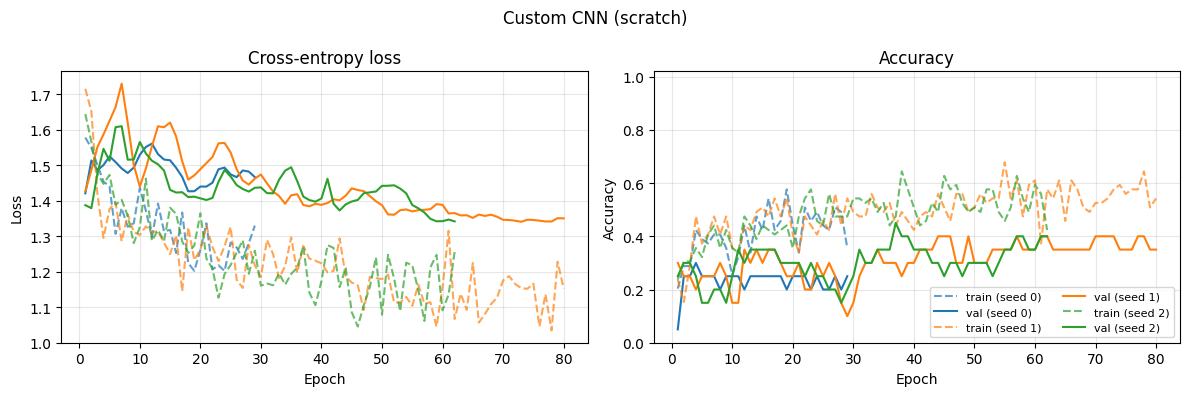

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
for i, (seed, h) in enumerate(histories.items()):
    for ax, metric in zip(axes, ("loss", "acc")):
        ax.plot(h["epoch"], h[f"train_{metric}"], "--", color=colors[i], alpha=0.7, label=f"train (seed {seed})")
        ax.plot(h["epoch"], h[f"val_{metric}"], "-", color=colors[i], label=f"val (seed {seed})")
axes[0].set(title="Cross-entropy loss", xlabel="Epoch", ylabel="Loss")
axes[1].set(title="Accuracy", xlabel="Epoch", ylabel="Accuracy", ylim=(0, 1.02))
for ax in axes:
    ax.grid(alpha=0.3)
axes[1].legend(fontsize=8, loc="lower right", ncol=2)
fig.suptitle(DISPLAY_NAME)
fig.tight_layout()
fig.savefig(RESULTS_DIR / "training_curves.png", dpi=150, bbox_inches="tight")

**Test-set confusion matrix** (counts and row-normalised %; left = representative run chosen by validation accuracy, right = pooled over all seeds):

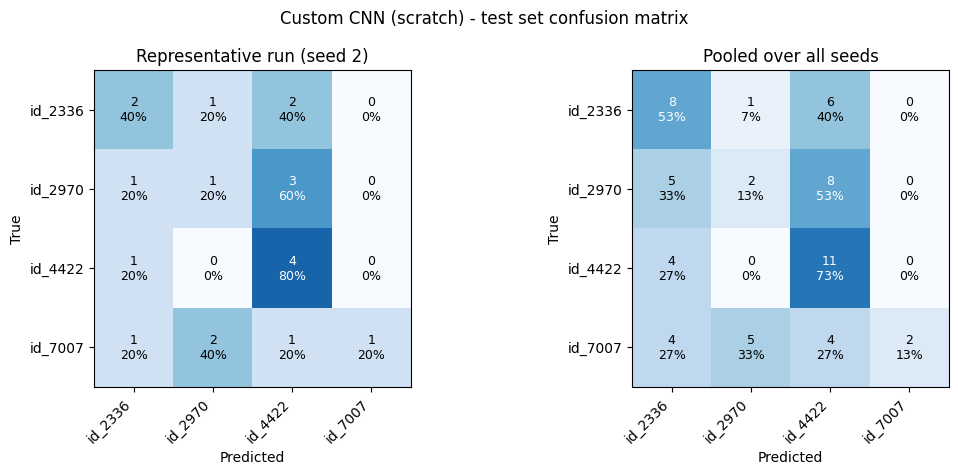

In [ ]:
def draw_confusion_matrix(ax, cm, title):
    cm = np.asarray(cm)
    row_pct = cm / cm.sum(1, keepdims=True).clip(min=1)
    ax.imshow(row_pct, cmap="Blues", vmin=0, vmax=1)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, f"{cm[i, j]}\n{row_pct[i, j]:.0%}", ha="center", va="center",
                    color="white" if row_pct[i, j] > 0.5 else "black", fontsize=9)
    ax.set_xticks(range(len(class_names)), class_names, rotation=45, ha="right")
    ax.set_yticks(range(len(class_names)), class_names)
    ax.set(xlabel="Predicted", ylabel="True", title=title)


fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))
draw_confusion_matrix(axes[0], cm, f"Representative run (seed {rep_seed})")
draw_confusion_matrix(axes[1], cm_pooled, "Pooled over all seeds")
fig.suptitle(f"{DISPLAY_NAME} - test set confusion matrix")
fig.tight_layout()
fig.savefig(RESULTS_DIR / "confusion_matrix.png", dpi=150, bbox_inches="tight")

In [ ]:
print("Per-class test accuracy (mean over seeds):")
display(pd.Series(metrics["per_class_accuracy"], name="accuracy").round(3).to_frame().T)
print("Classification report (representative run):")
display(pd.DataFrame(metrics["classification_report"]).T.round(3))

Per-class test accuracy (mean over seeds):


,id_2336,id_2970,id_4422,id_7007
accuracy,0.533,0.133,0.733,0.133


Classification report (representative run):


,precision,recall,f1-score,support
id_2336,0.400,0.4,0.400,5.0
id_2970,0.250,0.2,0.222,5.0
id_4422,0.400,0.8,0.533,5.0
id_7007,1.000,0.2,0.333,5.0
accuracy,0.400,0.4,0.400,0.4
macro avg,0.512,0.4,0.372,20.0
weighted avg,0.512,0.4,0.372,20.0


#### Observations
*Numbers below are from our Colab run (Tesla T4, seeds 0-2). A rerun can differ; the tables above always show the current run.*

* **Test accuracy 38.3% ± 7.6%** (chance = 25%), macro-F1 0.33. Per seed: 30%, 45% and 40%.
* **Unstable across seeds.** Seed 0 never took off: validation accuracy stayed at 20-30% after epoch 4, so early
  stopping (patience 25) ended it at epoch 29 and kept a near-chance model (30% test). Seeds 1 and 2 learned slowly
  (best epochs 73 and 37; seed 1 was still improving at epoch 80). An earlier CPU run of the same code and seeds
  reached 51.7% ± 2.9%. GPU and CPU generate different random numbers (e.g. dropout masks), so the two runs follow
  different training paths. The gap between them shows how much the scratch model's result depends on chance.
* **Under-fitting from lack of data, not over-fitting.** Training accuracy (measured with augmentation and dropout
  active) stays below 70%, and validation accuracy reaches only 35-45% in the runs that learned. With 59 training
  images, a network trained from random weights cannot learn identity-specific facial features.
* **Identity level (pooled over seeds):** `id_4422` (73%) and `id_2336` (53%) are recognised best, `id_2970` and
  `id_7007` only 13%. The model over-predicts `id_4422` (29 of 60 test predictions) and almost never predicts
  `id_7007` (2 of 60). Most `id_2970` images are labelled as its look-alike `id_4422` (8 of 15).
* **Cost:** smallest model (0.98 M parameters, 3.8 MB); 48 s per training run and 1.3 ms/image inference on a T4.
  Its accuracy is far too low for the detection pipeline.